# Keras Regression Code Along Project

Let's now apply our knowledge to a more realistic data set. Here we will also focus on feature engineering and cleaning our data!

## The Data

We will be using data from a Kaggle data set:

https://www.kaggle.com/harlfoxem/housesalesprediction

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('kc_house_data.csv')

# Exploratory Data Analysis

In [7]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


C:\Users\96650\AppData\Local\Temp\ipykernel_31616\293081956.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


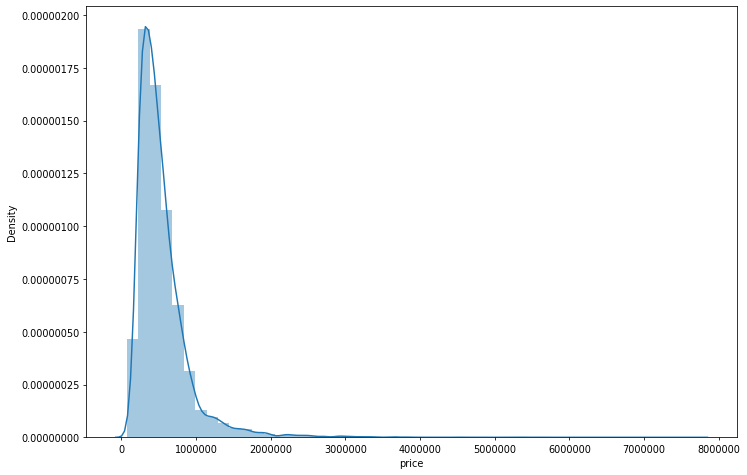

In [9]:
plt.figure(figsize=(12,8), dpi=70)
sns.distplot(df['price'])
plt.ticklabel_format(style='plain', axis='both')
plt.show()


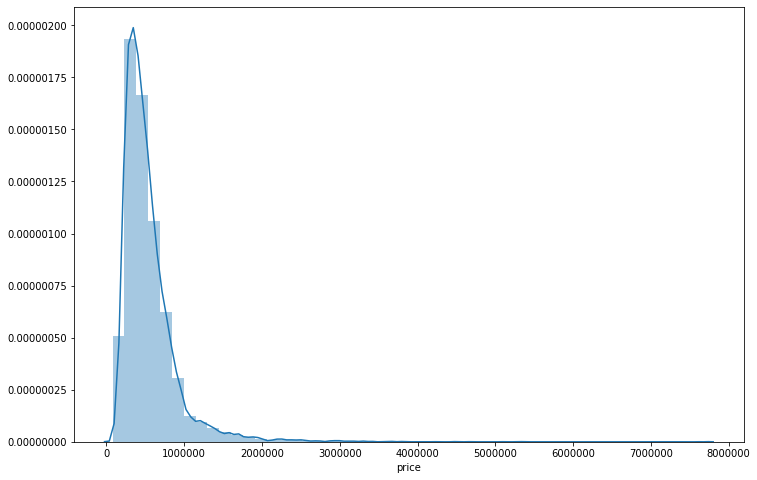

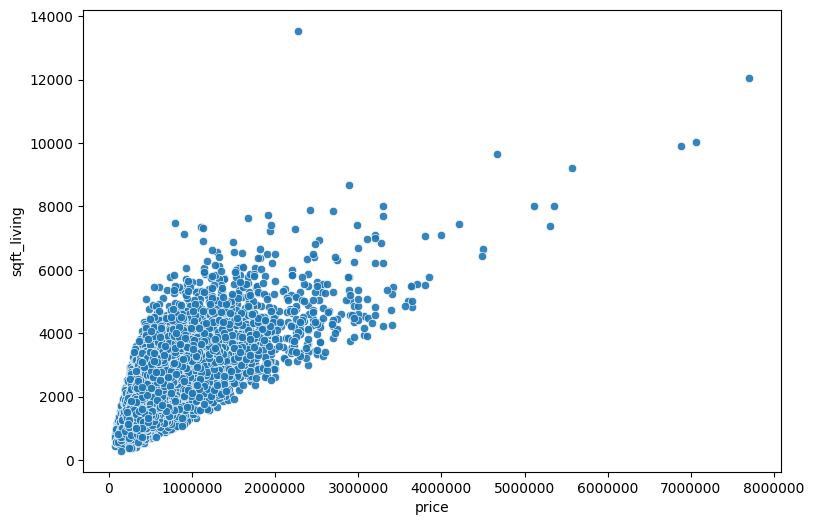

In [10]:
plt.figure(figsize=(9,6))

sns.scatterplot(x=df["price"], y=df["sqft_living"], alpha=0.9)

plt.ticklabel_format(style='plain', axis='x')

plt.xlabel("price")
plt.ylabel("sqft_living")

plt.show()

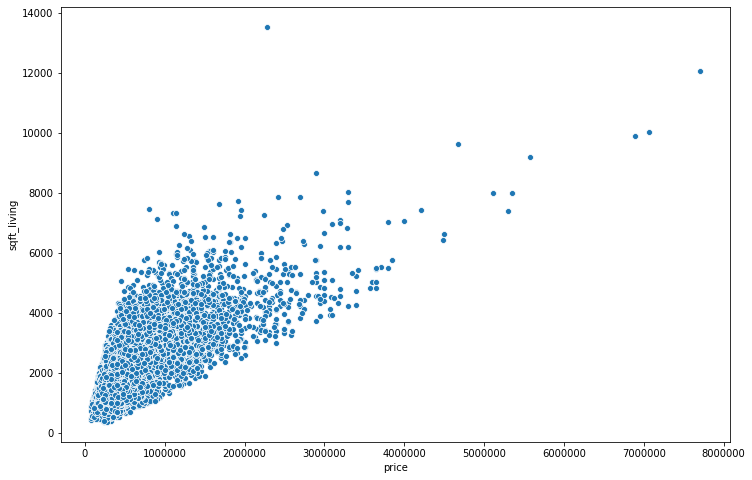

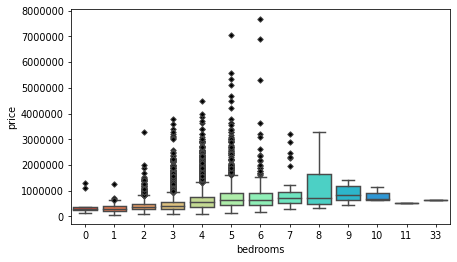

In [6]:
plt.figure(figsize=(7,4), dpi=70)

sns.boxplot(
    x=df["bedrooms"],
    y=df["price"],
    # reverse rainbow palette
    palette="rainbow_r",
    flierprops=dict(marker='D', markerfacecolor='black', markersize=4)   # diamond marker
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("bedrooms")
plt.ylabel("price")


plt.show()

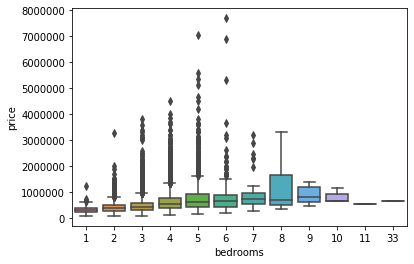

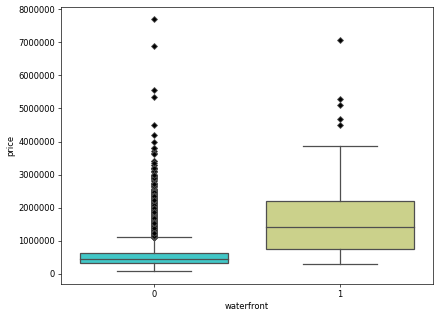

In [7]:
plt.figure(figsize=(8,6), dpi=60)

sns.boxplot(
    x=df["waterfront"],
    y=df["price"],
    palette="rainbow",
    flierprops=dict(marker='D', markerfacecolor='black', markersize=5)
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("waterfront")
plt.ylabel("price")

plt.show()

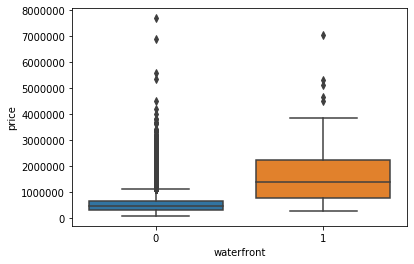

## Working with Feature Data

In [8]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [12]:
df.drop('id', axis=1, inplace=True)

In [13]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


- There is difference between the dataframes

### Feature Engineering from Date

In [14]:
#Convert 'date' to date time
df['date'] = pd.to_datetime(df['date'])


In [15]:
# make columns for month and year
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

C:\Users\96650\AppData\Local\Temp\ipykernel_31616\3763758962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


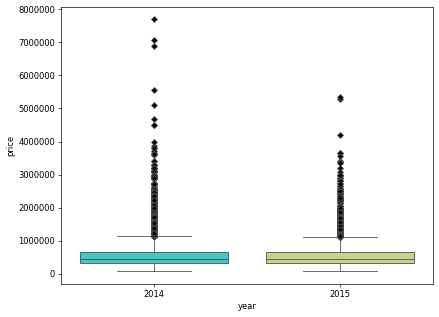

In [16]:
plt.figure(figsize=(8,6), dpi=60)

sns.boxplot(
    x=df["year"],
    y=df["price"],
    palette="rainbow",
    flierprops=dict(marker='D', markerfacecolor='black', markersize=5)
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("year")
plt.ylabel("price")

plt.show()

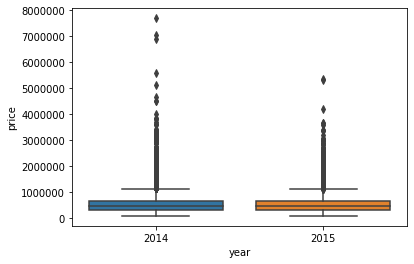

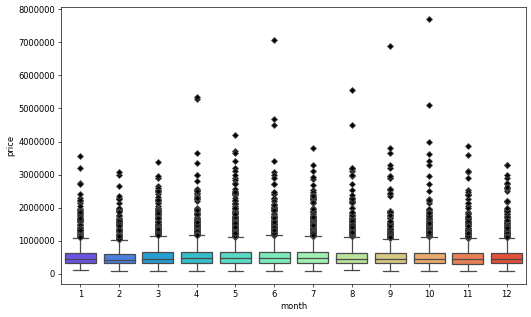

In [15]:
plt.figure(figsize=(10,6), dpi=60)

sns.boxplot(
    data=df,
    x="month",
    y="price",
    palette="rainbow",
    flierprops=dict(marker='D', markerfacecolor='black', markersize=5)
)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("month")
plt.ylabel("price")

plt.show()

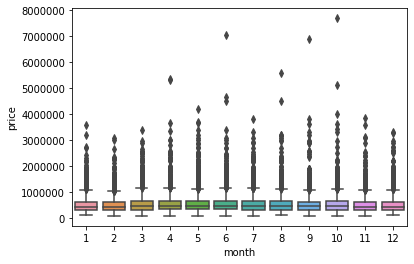

In [17]:
df.drop('date', axis=1, inplace=True)

In [18]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')

## Scaling and Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('price',axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)


### Scaling

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
X_train.shape

(15129, 20)

In [22]:
X_test.shape

(6484, 20)

## Creating a Model

In [26]:
pip install tensorflow

   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/350.6 MB 4.9 MB/s eta 0:01:11
   ---------------------------------------- 3.4/350.6 MB 6.3 MB/s eta 0:00:56
    --------------------------------------- 5.2/350.6 MB 7.1 MB/s eta 0:00:49
    --------------------------------------- 7.1/350.6 MB 7.5 MB/s eta 0:00:46
    --------------------------------------- 8.4/350.6 MB 7.1 MB/s eta 0:00:49
   - -------------------------------------- 10.0/350.6 MB 7.2 MB/s eta 0:00:48
   - -------------------------------------- 11.3/350.6 MB 7.2 MB/s eta 0:00:48
   - -------------------------------------- 13.4/350.6 MB 7.4 MB/s eta 0:00:46
   - -------------------------------------- 14.7/350.6 MB 7.4 MB/s eta 0:00:46
   - -------------------------------------- 15.7/350.6 MB 7.0 MB/s eta 0:00:48
  

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

## Training the Model

In [28]:
model = Sequential()

model.add(Dense(20,activation='relu')) # 20 input cols, relu as a safe option.
model.add(Dense(18,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(14,activation='relu'))
model.add(Dense(1)) # output

model.compile(optimizer='adam',loss='mse')

In [29]:
model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values),
          batch_size=128,epochs=400)
# batch size is usually powers of two. given our data, 21000/128 = 164 batch
# small batch size = slow training, better genarlizing. v large b size = faster, prone for overfitting.

Epoch 1/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 419687923712.0000 - val_loss: 442182008832.0000
Epoch 2/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 418763636736.0000 - val_loss: 438995746816.0000
Epoch 3/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 406421209088.0000 - val_loss: 409879609344.0000
Epoch 4/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 344935694336.0000 - val_loss: 304581836800.0000
Epoch 5/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 209300865024.0000 - val_loss: 154370015232.0000
Epoch 6/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 111877447680.0000 - val_loss: 112043589632.0000
Epoch 7/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99227500544.0000 - val_loss: 109483466752.0000
Epoch 8/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 97631748096.0000 - val_loss: 107706040320.0000
Epoch 9/400
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 96099426304.0000 - val_loss: 106093232128.0000
Epoch 10/400
119/119 ━

Train on 15117 samples, validate on 6480 samples
Epoch 1/400
15117/15117 [==============================] - 1s 74us/sample - loss: 430228839929.3955 - val_loss: 418844493758.2617
Epoch 2/400
15117/15117 [==============================] - 0s 21us/sample - loss: 428253102583.9730 - val_loss: 411996069786.8642
Epoch 3/400
15117/15117 [==============================] - 0s 21us/sample - loss: 401401261499.3472 - val_loss: 351554389222.0839
Epoch 4/400
15117/15117 [==============================] - 0s 22us/sample - loss: 281418027052.1653 - val_loss: 178278463958.2815
Epoch 5/400
15117/15117 [==============================] - 0s 21us/sample - loss: 126127754575.5078 - val_loss: 95946680446.4198
Epoch 6/400
15117/15117 [==============================] - 0s 21us/sample - loss: 97670204498.9794 - val_loss: 93708013133.1160
Epoch 7/400
15117/15117 [==============================] - 0s 21us/sample - loss: 95694764310.6754 - val_loss: 91793937901.0370
Epoch 8/400
15117/15117 [=====================

15117/15117 [==============================] - 0s 21us/sample - loss: 32665666133.9938 - val_loss: 31180875164.1284
Epoch 128/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32611257821.4873 - val_loss: 31133322960.5926
Epoch 129/400
15117/15117 [==============================] - 0s 20us/sample - loss: 32587610780.3061 - val_loss: 31109388368.9086
Epoch 130/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32532602761.3225 - val_loss: 31070066824.5333
Epoch 131/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32522762140.2215 - val_loss: 31049869848.0198
Epoch 132/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32456779739.7600 - val_loss: 30991022889.0864
Epoch 133/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32441568509.6800 - val_loss: 31072597773.2741
Epoch 134/400
15117/15117 [==============================] - 0s 20us/sample - loss: 32410024930.5338 - v

15117/15117 [==============================] - 0s 21us/sample - loss: 30409109880.6250 - val_loss: 28668203351.8617
Epoch 254/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30455913509.4593 - val_loss: 28813098750.1037
Epoch 255/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30437949613.1391 - val_loss: 28386738110.2617
Epoch 256/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30388506209.7040 - val_loss: 28367340799.3679
Epoch 257/400
15117/15117 [==============================] - 0s 20us/sample - loss: 30382620658.2491 - val_loss: 28331952921.9160
Epoch 258/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30362880877.7530 - val_loss: 28368884743.5852
Epoch 259/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30377130940.6004 - val_loss: 28326146690.2123
Epoch 260/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30345498520.2249 - v

15117/15117 [==============================] - 0s 21us/sample - loss: 29184432503.5073 - val_loss: 26707127121.5407
Epoch 380/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29192302663.5317 - val_loss: 26916886057.7185
Epoch 381/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29209242404.8666 - val_loss: 26659705383.1901
Epoch 382/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29177634422.7114 - val_loss: 26732598608.2765
Epoch 383/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29162964032.4191 - val_loss: 26640063419.7333
Epoch 384/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29135119725.1095 - val_loss: 26646387926.9136
Epoch 385/400
15117/15117 [==============================] - 0s 20us/sample - loss: 29150060664.3032 - val_loss: 26652868825.4420
Epoch 386/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29143038606.3521 - v

In [30]:
losses = pd.DataFrame(model.history.history)

<Axes: >

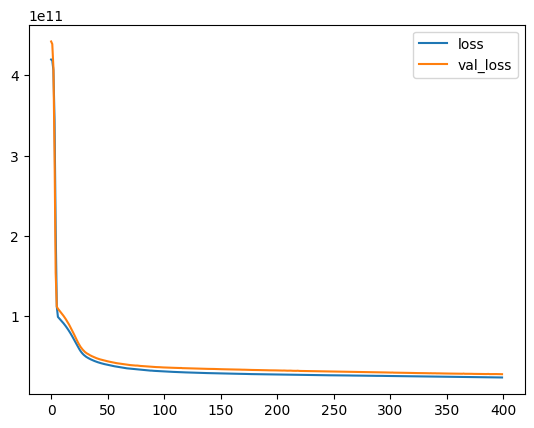

In [31]:
losses.plot()

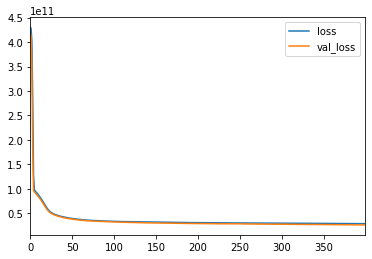

In [ ]:
losses.plot()

# Evaluation on Test Data

https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

In [32]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

In [33]:
predictions = model.predict(X_test)
# mean squared error
print(mean_squared_error(y_test,predictions))
# mean absolute error
print(mean_absolute_error(y_test,predictions))
# explained variance score
print(explained_variance_score(y_test,predictions))

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step
27911003169.301968
102748.26989512646
0.8071191706505438


* The model achieves **MAE ≈ 99,600**, meaning predictions are on average about **$100k away from the true house price**.
* The **explained variance score ≈ 0.81**, indicating the network captures about **81% of the variability in housing prices**.
* The large **MSE (~2.7×10¹⁰)** is expected because price values are large and squared errors amplify deviations.
* Some error is likely due to the **right-skewed price distribution and luxury outliers** in the dataset.
* Additionally, **neural networks are not always optimal for tabular housing data**, where tree-based models often perform better.


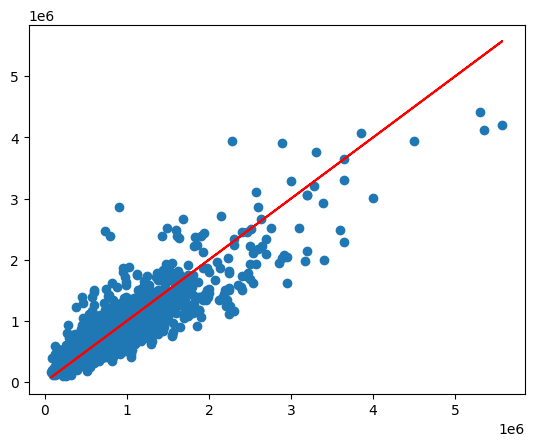

In [34]:

plt.scatter(y_test,predictions)
plt.plot(y_test,y_test,'r')

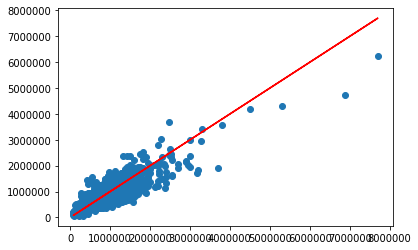

In [35]:
import pickle

with open("scaler_weights.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("model_weights.pkl", "wb") as f:
    pickle.dump(model, f)

# Results
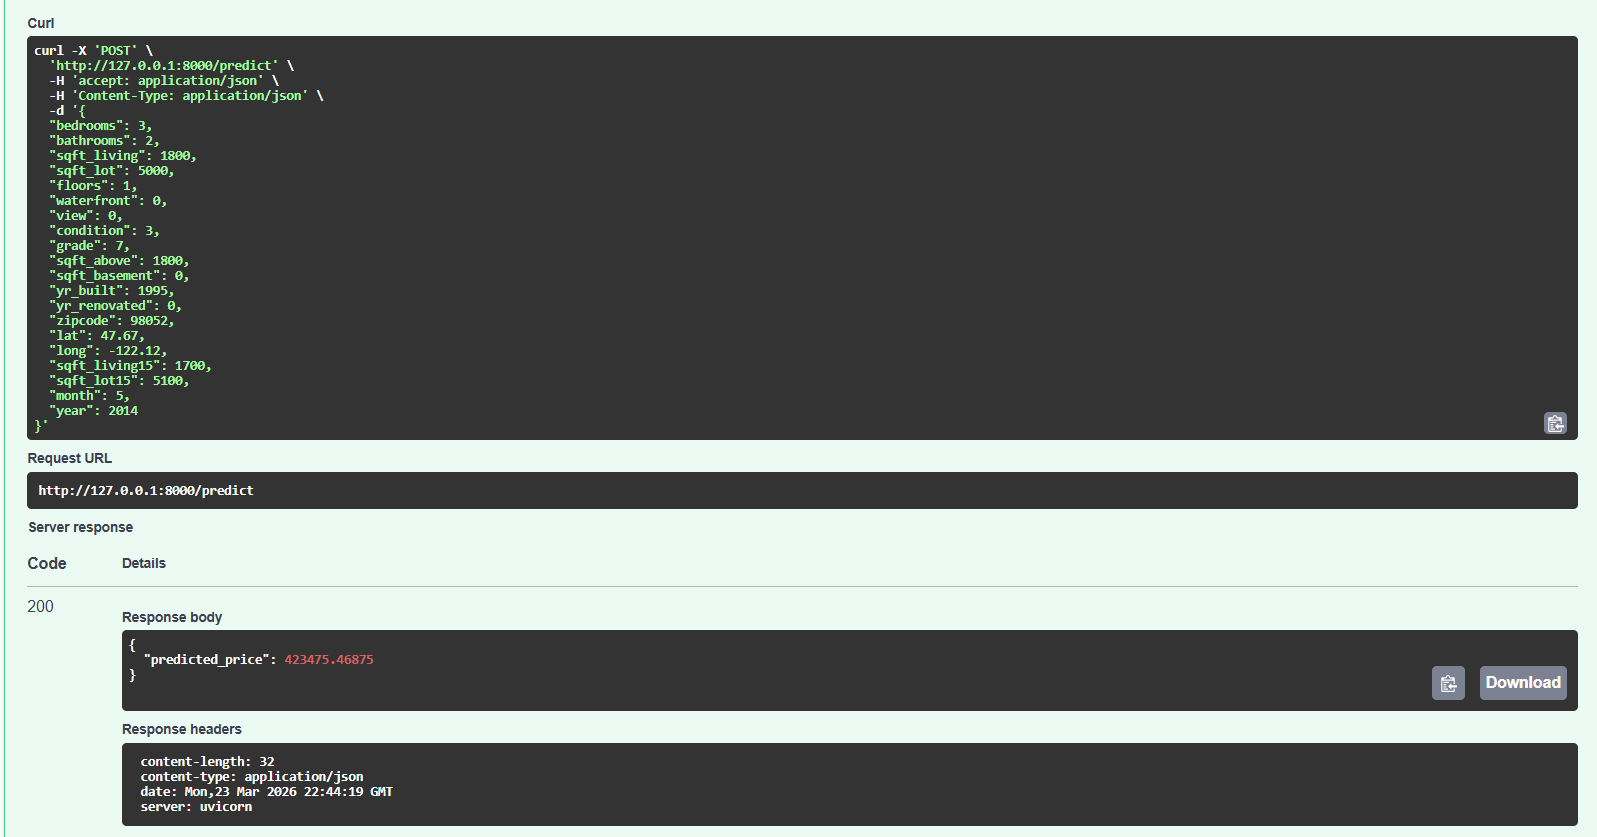